In [49]:
import xarray as xr
import pandas as pd
import numpy as np
import torch
import cv2
import os

#print(os.getcwd())
os.chdir('..')
#print(os.getcwd())

from utils import noise_at_level, crop_centered_window, plot_perturbation

from metrics import DataStructuralSimilarityIndex, NormalizedRootMeanSquaredError
from wavelet_base import Wavelet2DBaseTorch
from wavesim import WaveSim

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load Precipitation Data

In [50]:
# ground truth / reference
era5_ds = xr.open_zarr('gs://weatherbench2/datasets/era5/1959-2022-6h-1440x721.zarr', consolidated=True, decode_timedelta=True)
hres_ds = xr.open_zarr('gs://weatherbench2/datasets/hres/2016-2022-0012-1440x721.zarr', consolidated=True, decode_timedelta=True)

In [51]:
ref_day_reanalysis = '2016-01-02T06:00:000000000'
ref_day_forecasts = '2016-01-01T00:00:000000000'
lead_time = '1 days 06:00:00'

reanalysis_field = era5_ds.sel(time=ref_day_reanalysis, method='nearest').sortby('latitude').total_precipitation_6hr
forecast_field = hres_ds.sel(time=ref_day_forecasts, prediction_timedelta=lead_time).total_precipitation_6hr

## Convert precipition from meters to millimeters

In [52]:
reanalysis_field = reanalysis_field * 1000.0
forecast_field = forecast_field * 1000.0

# 0. Scores DataFrame

In [53]:
scores = pd.DataFrame(columns=['perturbation_type', 
                               'perturbation_params', 
                               'nrmse', 
                               'dssim', 
                               #'haar_psi', 
                               'wavesim',
                               'wavesim_components',
                               ]).astype({
                                        'perturbation_type': 'str', 
                                        'perturbation_params': 'str',
                                        'nrmse': np.float32,
                                        'dssim': np.float32,
                                        #'haar_psi': np.float32,
                                        'wavesim': np.float32,
                                        'wavesim_components': 'str',
                                        })

spatial_perturbations = {}

# 1. Spatial perturbations

## Cropping across a region in Europe

In [54]:
# centroid coordinates in Europe
center_lon = 10.0
center_lat = 49.75
patch_size = 256
shift_lon_deg = 0.0 # we don't shift here; it's the reference map
shift_lat_deg = 0.0 # we don't shift here; it's the reference map
reference = crop_centered_window(reanalysis_field, 
                                 center_lon = center_lon, 
                                 center_lat = center_lat, 
                                 size_lon = patch_size, 
                                 size_lat = patch_size, 
                                 shift_lon_deg = shift_lon_deg, 
                                 shift_lat_deg = shift_lat_deg)

## Perturbation #1 : spatial shift

### Case 1 : -1 deg longitudes

In [55]:
shift_lon_deg = -1.0
shift_lat_deg = 0.0
shifted_case_1 = crop_centered_window(reanalysis_field, 
                                      center_lon = center_lon, 
                                      center_lat = center_lat, 
                                      size_lon = patch_size,
                                      size_lat = patch_size,
                                      shift_lon_deg = shift_lon_deg,
                                      shift_lat_deg = shift_lat_deg)

params = {'shift_lon_deg' : shift_lon_deg, 'shift_lat_deg' : shift_lat_deg}
spatial_perturbations.update({'shifted_case_1' : {'perturbation_params' : params, 'values' : shifted_case_1.values}})

Bias min: -11.061029434204102, max: 11.345542907714844


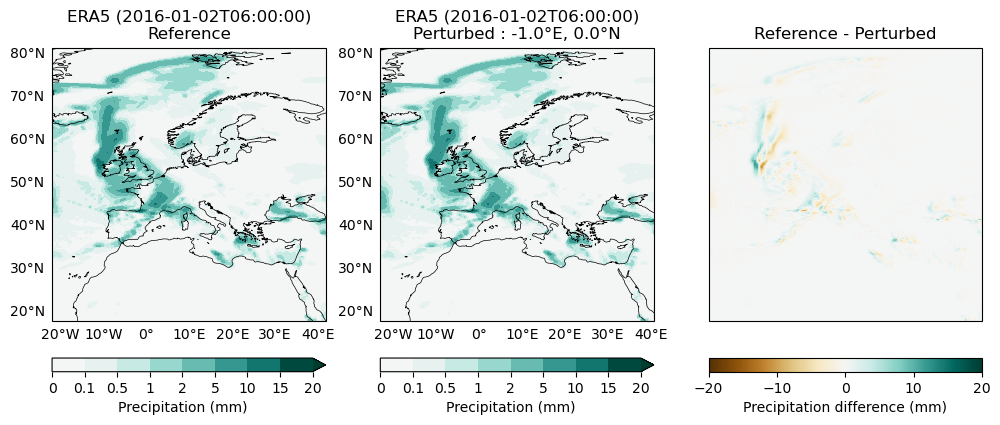

In [56]:
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : {shift_lon_deg}°E, {shift_lat_deg}°N'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (shifted_case_1.longitude, shifted_case_1.latitude)
plot_perturbation(reference=reference.values, perturbed=shifted_case_1.values, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label)

### Case 2 : -2 deg longitudes, 0 deg latitude

In [57]:
shift_lon_deg = -2.0
shift_lat_deg = 0.0
shifted_case_2 = crop_centered_window(reanalysis_field, 
                                      center_lon = center_lon, 
                                      center_lat = center_lat, 
                                      size_lon = patch_size,
                                      size_lat = patch_size,
                                      shift_lon_deg = shift_lon_deg,
                                      shift_lat_deg = shift_lat_deg)

params = {'shift_lon_deg' : shift_lon_deg, 'shift_lat_deg' : shift_lat_deg}
spatial_perturbations.update({'shifted_case_2' : {'perturbation_params' : params, 'values' : shifted_case_2.values}})

Bias min: -13.528972625732422, max: 13.781776428222656


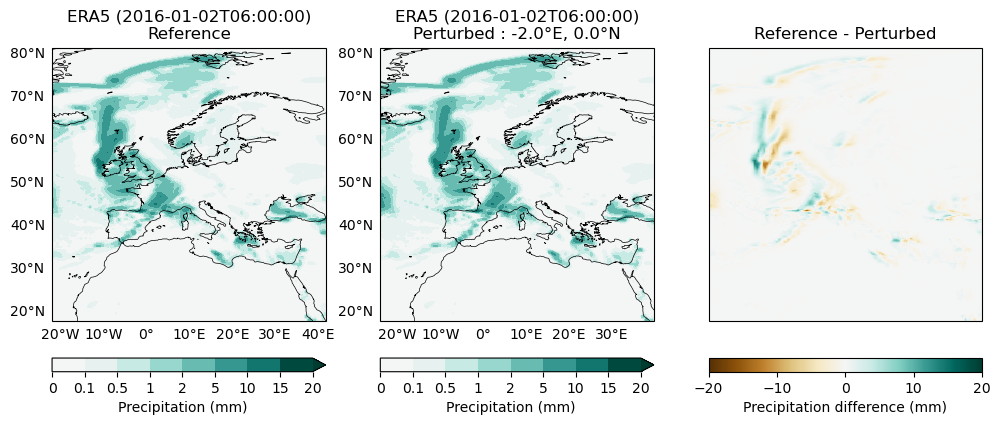

In [58]:
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : {shift_lon_deg}°E, {shift_lat_deg}°N'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (shifted_case_2.longitude, shifted_case_2.latitude)
plot_perturbation(reference=reference.values, perturbed=shifted_case_2.values, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label)

### Case 3 : -10 deg longitudes

In [59]:
shift_lon_deg = -10.0
shift_lat_deg = 0.0
shifted_case_3 = crop_centered_window(reanalysis_field, 
                                      center_lon = center_lon, 
                                      center_lat = center_lat, 
                                      size_lon = patch_size,
                                      size_lat = patch_size,
                                      shift_lon_deg = shift_lon_deg,
                                      shift_lat_deg = shift_lat_deg)

params = {'shift_lon_deg' : shift_lon_deg, 'shift_lat_deg' : shift_lat_deg}
spatial_perturbations.update({'shifted_case_3' : {'perturbation_params' : params, 'values' : shifted_case_3.values}})

Bias min: -13.269659042358398, max: 13.87282657623291


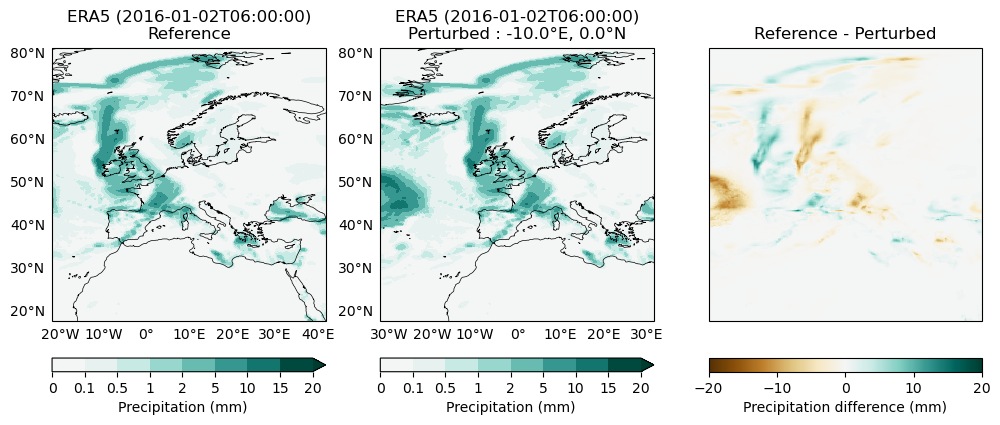

In [60]:
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : {shift_lon_deg}°E, {shift_lat_deg}°N'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (shifted_case_3.longitude, shifted_case_3.latitude)
plot_perturbation(reference=reference.values, perturbed=shifted_case_3.values, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label)

### Case 4 : -10 deg longitudes, -10 deg latitude

In [61]:
shift_lon_deg = -10.0
shift_lat_deg = -10.0
shifted_case_4 = crop_centered_window(reanalysis_field, 
                                      center_lon = center_lon, 
                                      center_lat = center_lat, 
                                      size_lon = patch_size,
                                      size_lat = patch_size,
                                      shift_lon_deg = shift_lon_deg,
                                      shift_lat_deg = shift_lat_deg)

params = {'shift_lon_deg' : shift_lon_deg, 'shift_lat_deg' : shift_lat_deg}
spatial_perturbations.update({'shifted_case_4' : {'perturbation_params' : params, 'values' : shifted_case_4.values}})

Bias min: -14.496316909790039, max: 14.436973571777344


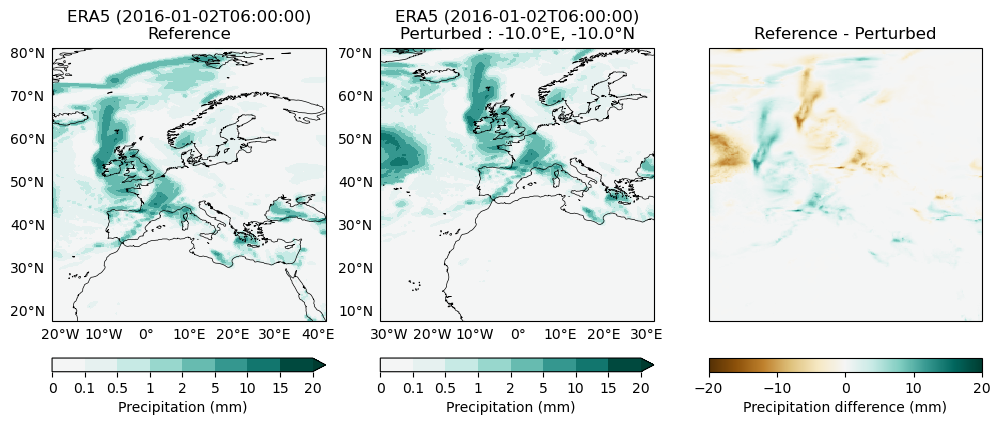

In [62]:
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : {shift_lon_deg}°E, {shift_lat_deg}°N'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (shifted_case_4.longitude, shifted_case_4.latitude)
plot_perturbation(reference=reference.values, perturbed=shifted_case_4.values, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label)

### Case 5 : -40 deg longitudes, -60 deg latitude

In [63]:
shift_lon_deg = -40.0
shift_lat_deg = -60.0
shifted_case_5 = crop_centered_window(reanalysis_field, center_lon = 10.0, center_lat = 49.75, size_lon=256, size_lat=256, shift_lon_deg=shift_lon_deg, shift_lat_deg=shift_lat_deg)
params = {'shift_lon_deg' : shift_lon_deg, 'shift_lat_deg' : shift_lat_deg}
spatial_perturbations.update({'shifted_case_5' : {'perturbation_params' : params, 'values' : shifted_case_5.values}})

Bias min: -90.02460479736328, max: 14.500377655029297


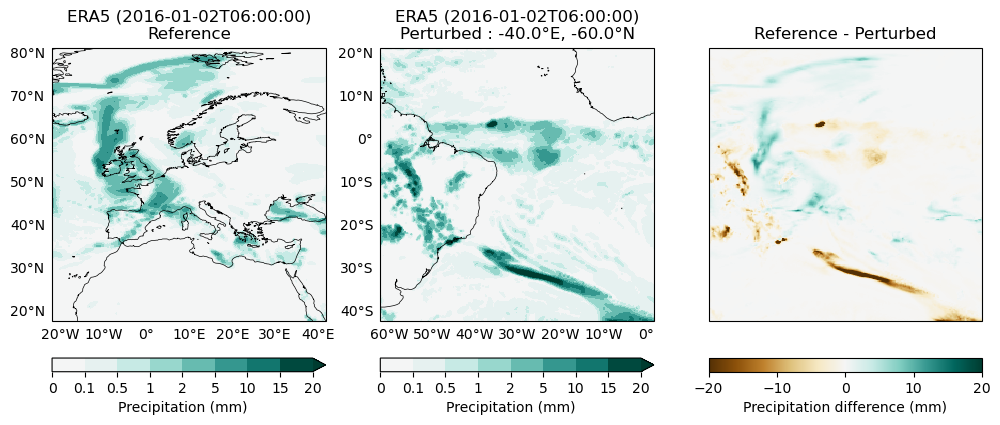

In [64]:
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : {shift_lon_deg}°E, {shift_lat_deg}°N'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (shifted_case_5.longitude, shifted_case_5.latitude)
plot_perturbation(reference=reference.values, perturbed=shifted_case_5.values, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label)

## Perturbation #2 : flip

### Case 1 : Horizontal flip

In [65]:
flip_case_1 = np.fliplr(reference.copy().values)
params = {'flip' : 'horizontal'}
spatial_perturbations.update({'flip_case_1' : {'perturbation_params' : params, 'values' : flip_case_1}})

Bias min: -14.240251541137695, max: 14.240251541137695


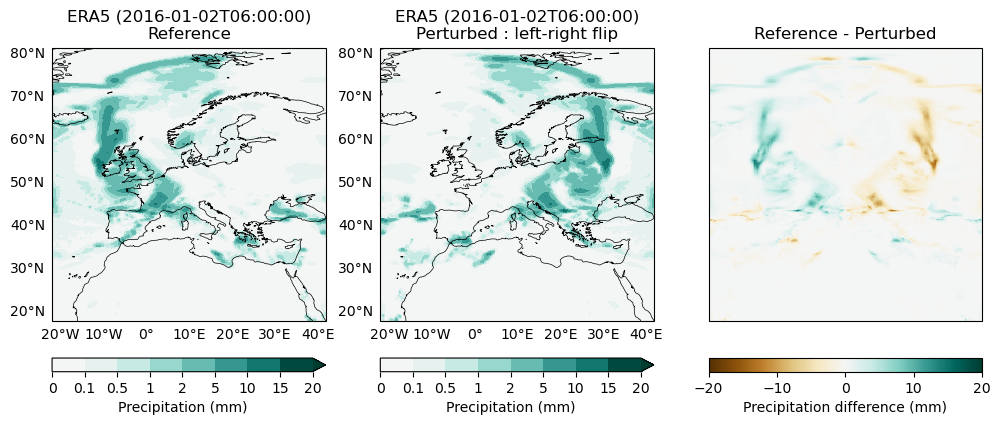

In [66]:
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : left-right flip'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (reference.longitude, reference.latitude)
plot_perturbation(reference=reference.values, perturbed=flip_case_1, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label)

### Case 2 : Vertical flip

In [67]:
flip_case_2 = np.flipud(reference.copy().values)
params = {'flip' : 'vertical'}
spatial_perturbations.update({'flip_case_2' : {'perturbation_params' : params, 'values' : flip_case_2}})

Bias min: -13.590751647949219, max: 13.590751647949219


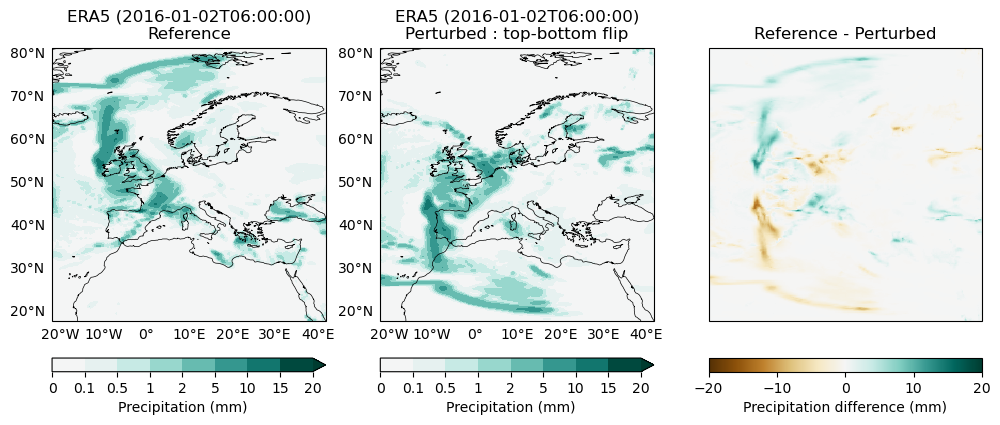

In [68]:
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : top-bottom flip'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (reference.longitude, reference.latitude)
plot_perturbation(reference=reference.values, perturbed=flip_case_2, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label)

### Case 3 : diagonal flip

In [69]:
flip_case_3 = reference.copy().values.T
params = {'flip' : 'diagonal'}
spatial_perturbations.update({'flip_case_3' : {'perturbation_params' : params, 'values' : flip_case_3}})

Bias min: -14.488998413085938, max: 14.488998413085938


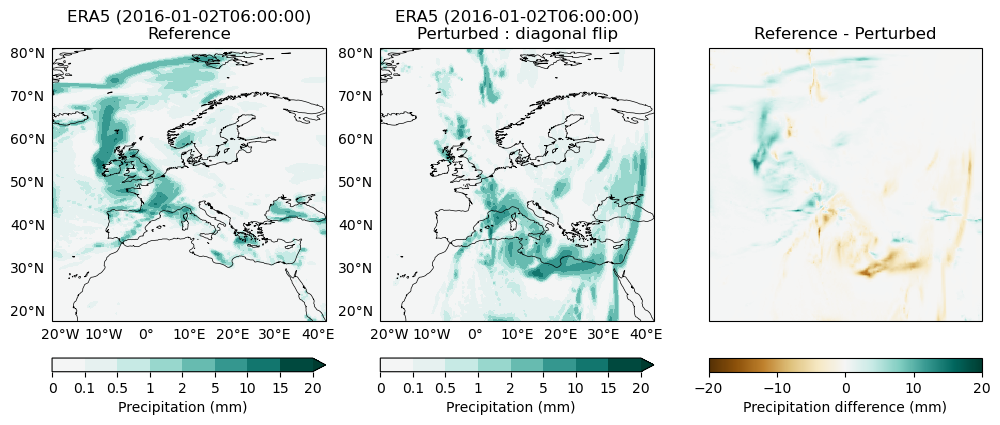

In [70]:
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : diagonal flip'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (reference.longitude, reference.latitude)
plot_perturbation(reference=reference.values, perturbed=flip_case_3, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label)

## Perturbation #3 : spatial upscaling

### Case 1 : scale factor : 0.5

In [71]:
scale_factor = 0.5
resized = cv2.resize(reference.values, (int(patch_size * scale_factor), int(patch_size * scale_factor)), interpolation=cv2.INTER_NEAREST)
upscale_case_1 = cv2.resize(resized, (patch_size, patch_size), interpolation=cv2.INTER_NEAREST)
params = {'scale_factor' : scale_factor}
spatial_perturbations.update({'upscale_case_1' : {'perturbation_params' : params, 'values' : upscale_case_1}})

Bias min: -5.976386070251465, max: 6.978684902191162


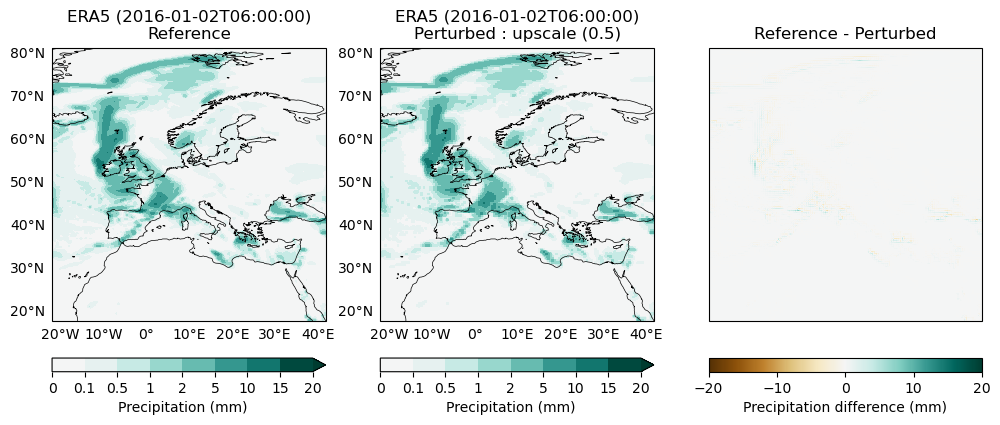

In [72]:
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : upscale ({scale_factor})'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (reference.longitude, reference.latitude)
plot_perturbation(reference=reference.values, perturbed=upscale_case_1, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label)

### Case 2 : scale factor 0.3

In [73]:
scale_factor = 0.3
resized = cv2.resize(reference.values, (int(patch_size * scale_factor), int(patch_size * scale_factor)), interpolation=cv2.INTER_NEAREST)
upscale_case_2 = cv2.resize(resized, (patch_size, patch_size), interpolation=cv2.INTER_NEAREST)
params = {'scale_factor' : scale_factor}
spatial_perturbations.update({'upscale_case_2' : {'perturbation_params' : params, 'values' : upscale_case_2}})

Bias min: -8.215091705322266, max: 13.611886978149414


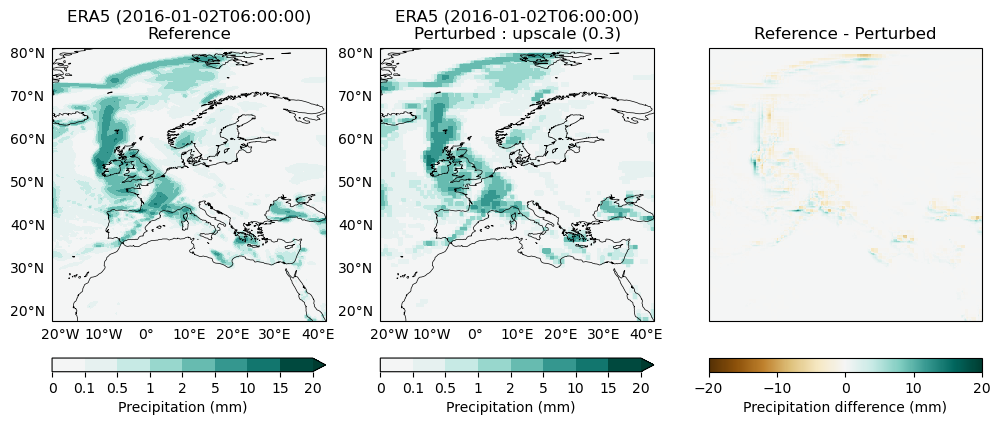

In [74]:
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : upscale ({scale_factor})'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (reference.longitude, reference.latitude)
plot_perturbation(reference=reference.values, perturbed=upscale_case_2, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label)

### Case 3 : scale factor 0.1

In [75]:
scale_factor = 0.1
resized = cv2.resize(reference.values, (int(patch_size * scale_factor), int(patch_size * scale_factor)), interpolation=cv2.INTER_NEAREST)
upscale_case_3 = cv2.resize(resized, (patch_size, patch_size), interpolation=cv2.INTER_NEAREST)
params = {'scale_factor' : scale_factor}
spatial_perturbations.update({'upscale_case_3' : {'perturbation_params' : params, 'values' : upscale_case_3}})

Bias min: -8.116732597351074, max: 13.048551559448242


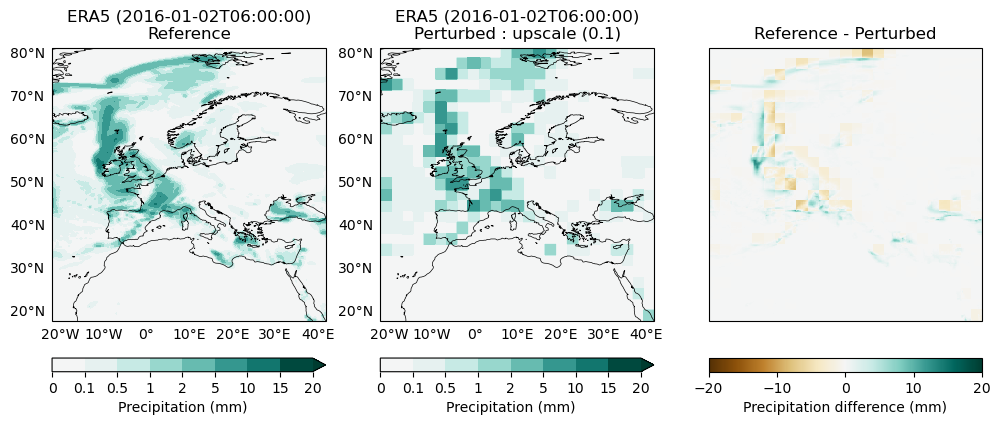

In [76]:
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : upscale ({scale_factor})'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (reference.longitude, reference.latitude)
plot_perturbation(reference=reference.values, perturbed=upscale_case_3, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label)

## Perturbation #4 : noise on different scales

### Case 1 : noise on approximation coefficients

In [77]:
magnitude = 1.0
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : Noise\nlarge scale (approx)'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (reference.longitude, reference.latitude)

Bias min: -2.4261934757232666, max: 2.3188531398773193


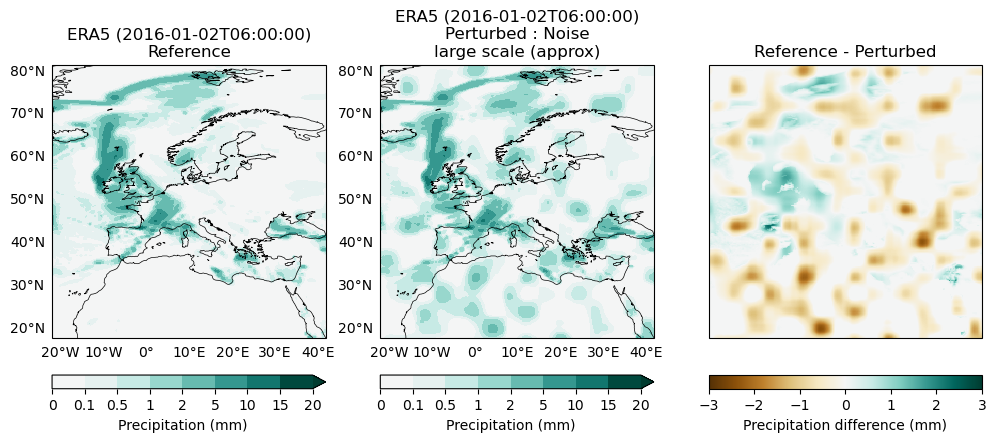

In [78]:
wavelet = Wavelet2DBaseTorch(torch.Tensor(reference.values.copy()).unsqueeze(0).unsqueeze(0), wavelet='db4', mode='zero', levels=4)
noise_case_1 = noise_at_level(wavelet=wavelet, magnitude=magnitude, level=-1, orientation=None, rand_state=32)
spatial_perturbations.update({'noise_case_1' : {'perturbation_params' : None, 'values' : noise_case_1}})
plot_perturbation(reference=reference.values, perturbed=noise_case_1, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label, cbar_lim = 3)

### Case 2 : noise on detail level 1 - horizontal orientation

In [79]:
magnitude = 1.0
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : Noise\nhorizontal details (level 1)'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (reference.longitude, reference.latitude)

Bias min: -0.5311376452445984, max: 0.491818368434906


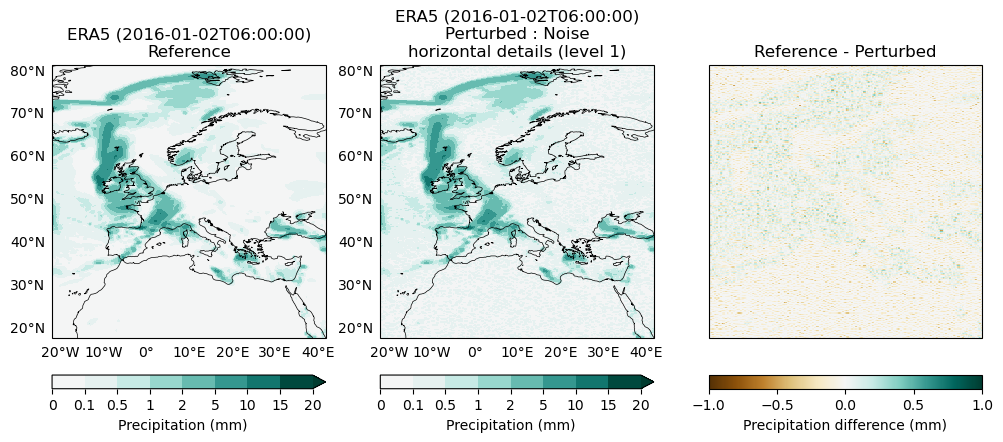

In [81]:
wavelet = Wavelet2DBaseTorch(torch.Tensor(reference.values.copy()).unsqueeze(0).unsqueeze(0), wavelet='db4', mode='zero', levels=4)
noise_case_2 = noise_at_level(wavelet=wavelet, magnitude=magnitude, level=1, orientation='H', rand_state=32)
spatial_perturbations.update({'noise_case_2' : {'perturbation_params' : None, 'values' : noise_case_2}})
plot_perturbation(reference=reference.values, perturbed=noise_case_2, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label, cbar_lim=1)

### Case 3 : noise on detail level 2 - vertical orientation

In [33]:
magnitude = 1.0
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : Noise\nvertical details (level 2)'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (reference.longitude, reference.latitude)

Bias min: -0.5022258162498474, max: 0.4196281433105469


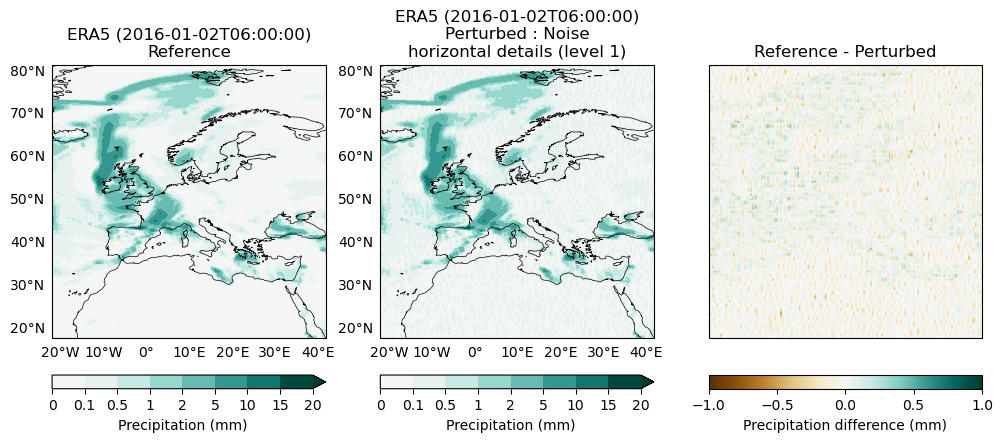

In [83]:
wavelet = Wavelet2DBaseTorch(torch.Tensor(reference.values.copy()).unsqueeze(0).unsqueeze(0), wavelet='db4', mode='zero', levels=4)
noise_case_3 = noise_at_level(wavelet=wavelet, magnitude=magnitude, level=2, orientation='V', rand_state=32)
spatial_perturbations.update({'noise_case_3' : {'perturbation_params' : None, 'values' : noise_case_3}})
plot_perturbation(reference=reference.values, perturbed=noise_case_3, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label, cbar_lim=1)

### Case 4 : noise on detail level 3 - diagonal orientation

In [35]:
magnitude = 1.0
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : Noise\ndiagonal details (level 3)'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (reference.longitude, reference.latitude)

Bias min: -0.5360962152481079, max: 0.46666550636291504


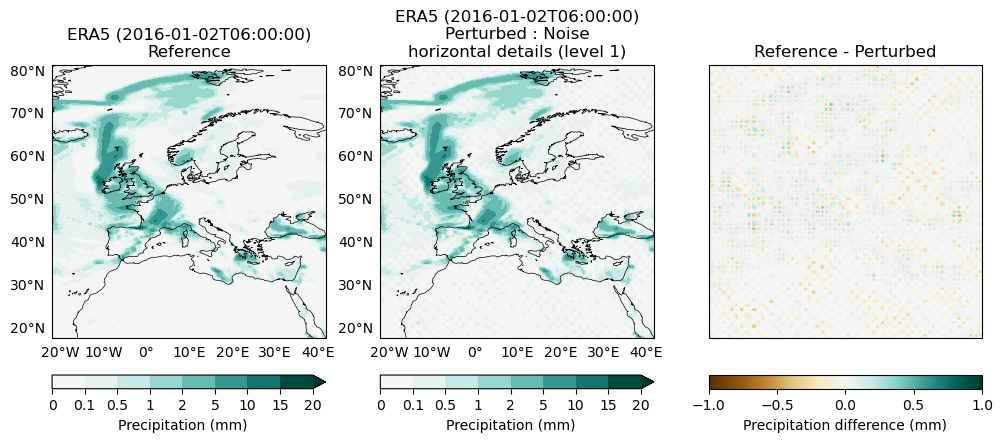

In [84]:
wavelet = Wavelet2DBaseTorch(torch.Tensor(reference.values.copy()).unsqueeze(0).unsqueeze(0), wavelet='db4', mode='zero', levels=4)
noise_case_4 = noise_at_level(wavelet=wavelet, magnitude=magnitude, level=3, orientation='D', rand_state=32)
spatial_perturbations.update({'noise_case_4' : {'perturbation_params' : None, 'values' : noise_case_4}})
plot_perturbation(reference=reference.values, perturbed=noise_case_4, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label, cbar_lim=1)

### Case 5 : noise on detail level 4 - horizontal orientation

In [37]:
magnitude = 1.0
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : Noise\nhorizontal details (level 4)'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (reference.longitude, reference.latitude)

Bias min: -0.9664731025695801, max: 0.7883105874061584


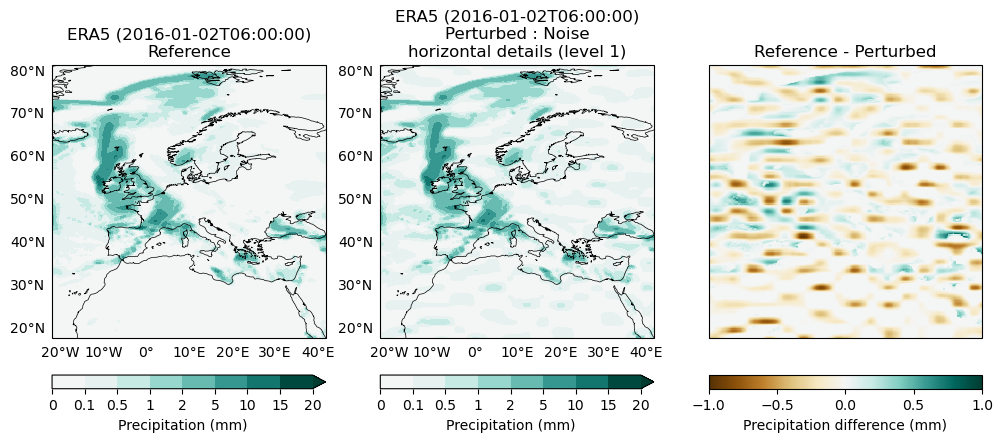

In [85]:
wavelet = Wavelet2DBaseTorch(torch.Tensor(reference.values.copy()).unsqueeze(0).unsqueeze(0), wavelet='db4', mode='zero', levels=4)
noise_case_5 = noise_at_level(wavelet=wavelet, magnitude=magnitude, level=4, orientation='H', rand_state=32)
spatial_perturbations.update({'noise_case_5' : {'perturbation_params' : None, 'values' : noise_case_5}})
plot_perturbation(reference=reference.values, perturbed=noise_case_5, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label, cbar_lim=1)

## Benchmark spatial perturbations

In [39]:
wavesim_params = {'wavelet': 'db4',
                'mode': 'zero',  ## 'zero', 'symmetric', 'reflect' or 'periodization'
                'levels': 4,
                'operation': 'sum',
                'components_weight': {'alpha': 1.0, 'beta': 1.0, 'gamma': 1.0},
                'scales_weight': [0.2, 0.2, 0.2, 0.2, 0.2] # TODO : transform in a tensor (B, C, L+1)
                }

dssim_params = {'C1' : 1.0e-8, 
                'C2' : 1.0e-8, 
                'k' : 5, 
                'std' : 1.5, 
                'ksize' : 11,  
                'discretize' : True,
                'return_contrast' : False}

nrsme_params = {'mode' : 'range'}

In [40]:
for perturbation_type, perturbation_dict in spatial_perturbations.items():
    print(f'Processing {perturbation_type}...')
    params, data = perturbation_dict['perturbation_params'], perturbation_dict['values']
    
    # Normalized Root Mean Squared Error
    nrmse_score = NormalizedRootMeanSquaredError(map1=reference.copy(), map2=data.copy(), params=nrsme_params).compute()
    
    # Data Structural Similarity Index Measure
    dssim_score = DataStructuralSimilarityIndex(map1=reference.copy(), map2=data.copy(), params=dssim_params).compute()
    
    # wavesim
    wavesim = WaveSim(map1=reference.copy(), map2=data.copy(), params=wavesim_params)
    wavesim_score = wavesim.compute()
    wavesim_components = {'magnitude': wavesim.magnitude_sim_score.numpy().ravel(),
                          'displacement': wavesim.displacement_sim_score.numpy().ravel(), 
                          'structural' : wavesim.structural_sim_score.numpy().ravel()
                          }
    
    new_row = pd.DataFrame({'perturbation_type' : [perturbation_type],
                                'perturbation_params' : [params], 
                                'nrmse' : [nrmse_score],
                                'dssim' : [dssim_score],
                                'wavesim' : [wavesim_score],
                                'wavesim_components' : [wavesim_components]
                                })
    
    scores = pd.concat([scores, new_row], ignore_index=True)

Processing shifted_case_1...
Processing shifted_case_2...
Processing shifted_case_3...
Processing shifted_case_4...
Processing shifted_case_5...
Processing flip_case_1...
Processing flip_case_2...
Processing flip_case_3...
Processing upscale_case_1...
Processing upscale_case_2...
Processing upscale_case_3...
Processing noise_case_1...
Processing noise_case_2...
Processing noise_case_3...
Processing noise_case_4...
Processing noise_case_5...


In [41]:
scores

,perturbation_type,perturbation_params,nrmse,dssim,wavesim,wavesim_components
0,shifted_case_1,"{'shift_lon_deg': -1.0, 'shift_lat_deg': 0.0}",0.949324,0.455023,0.891389,"{'magnitude': [0.98859626, 0.997053, 0.9376825..."
1,shifted_case_2,"{'shift_lon_deg': -2.0, 'shift_lat_deg': 0.0}",0.924923,0.310021,0.839507,"{'magnitude': [0.99452484, 0.9964428, 0.987535..."
2,shifted_case_3,"{'shift_lon_deg': -10.0, 'shift_lat_deg': 0.0}",0.875809,0.179748,0.524321,"{'magnitude': [0.91281265, 0.9499121, 0.905867..."
3,shifted_case_4,"{'shift_lon_deg': -10.0, 'shift_lat_deg': -10.0}",0.875572,0.188118,0.401493,"{'magnitude': [0.9348463, 0.9263281, 0.9976173..."
4,shifted_case_5,"{'shift_lon_deg': -40.0, 'shift_lat_deg': -60.0}",0.815334,0.157850,0.056644,"{'magnitude': [0.22490036, 0.12743193, 0.20944..."
5,flip_case_1,{'flip': 'horizontal'},0.889706,0.160421,0.524175,"{'magnitude': [0.9972659, 0.9803921, 0.9769344..."
6,flip_case_2,{'flip': 'vertical'},0.895829,0.100311,0.594348,"{'magnitude': [0.9925446, 0.99997264, 0.998133..."
7,flip_case_3,{'flip': 'diagonal'},0.893386,0.073488,0.348054,"{'magnitude': [0.99999994, 0.99999994, 0.99999..."
8,upscale_case_1,{'scale_factor': 0.5},0.980278,0.764820,0.764654,"{'magnitude': [0.5299468, 0.7582857, 0.9444512..."
9,upscale_case_2,{'scale_factor': 0.3},0.952694,0.392966,0.707127,"{'magnitude': [0.5556776, 0.99524915, 0.801532..."


In [42]:
case = 'shifted_case_1'

print(f'wavesim : {scores[scores['perturbation_type'] == case]['wavesim'].values[0]}')
print(f'magnitude : {scores[scores['perturbation_type'] == case]['wavesim_components'].values[0]['magnitude']}')
print(f'structural : {scores[scores['perturbation_type'] == case]['wavesim_components'].values[0]['structural']}')
print(f'displacement : {scores[scores['perturbation_type'] == case]['wavesim_components'].values[0]['displacement']}')

wavesim : 0.8913889527320862
magnitude : [0.98859626 0.997053   0.9376825  0.99518514 0.9836994 ]
structural : [0.9939273  0.9962616  0.97729903 0.9744782  0.97596884]
displacement : [0.8855888  0.91205806 0.91556823 0.9370179  0.9718879 ]


# 2. Temporal perturbations

In [43]:
# Spatial Domain of interest
# centroid coordinates in Europe
center_lon = 10.0
center_lat = 49.75
patch_size = 256
shift_lon_deg = 0.0 # we don't shift here
shift_lat_deg = 0.0 # we don't shift here

In [86]:
temporal_scores = pd.DataFrame(columns=['forecast init', 
                               'lead_time', 
                               'reanalysis',
                               'nrmse',
                               'dssim',
                               'wavesim',
                               'wavesim_components',
                               ]).astype({'forecast init': str, 
                                        'lead_time': str, 
                                        'reanalysis': str,
                                        'nrmse': np.float32,
                                        'dssim': np.float32,
                                        'wavesim': np.float32,
                                        'wavesim_components': 'str',
                               })

## Benchmark temporal perturbations

In [87]:
wavesim_temporal_params = {'wavelet': 'db4',
                'mode': 'zero',
                'levels': 4,
                'operation': 'sum',
                'components_weight': {'alpha': 1.0, 'beta': 1.0, 'gamma': 1.0},
                'scales_weight': [0.2, 0.2, 0.2, 0.2, 0.2] # TODO : transform in a tensor (B, C, L+1)
                }

In [46]:
ref_day_forecasts = '2016-01-01T00:00:000000000'

year = '2016'
month = '01'
init_day = 1
hour = '06:00:000000000'

wavesim_instances = []
for day in np.arange(1, 10):
    lead_time = f'{day} days 06:00:00'
    ref_day_reanalysis = f'{year}-{month}-{init_day + day:02d}T{hour}'
    print(f'Reanalysis : {ref_day_reanalysis[:-7]}')
    print(f'Forecast   : {ref_day_forecasts[:-7]} + {lead_time}')

    reanalysis_field = era5_ds.sel(time=ref_day_reanalysis, method='nearest').sortby('latitude').total_precipitation_6hr
    forecast_field = hres_ds.sel(time=ref_day_forecasts, prediction_timedelta=lead_time).total_precipitation_6hr

    reanalysis_field = reanalysis_field * 1000.0
    forecast_field = forecast_field * 1000.0

    reference_cropped = crop_centered_window(reanalysis_field, center_lon=center_lon, center_lat=center_lat, size_lon=patch_size, size_lat=patch_size, shift_lon_deg=shift_lon_deg, shift_lat_deg=shift_lat_deg)
    forecast_cropped = crop_centered_window(forecast_field, center_lon=center_lon, center_lat=center_lat, size_lon=patch_size, size_lat=patch_size, shift_lon_deg=shift_lon_deg, shift_lat_deg=shift_lat_deg)

    # clean negative values in precipitation fields
    reference_data = np.where(reference_cropped.values < 0.0, 0.0, reference_cropped.values)
    forecast_data = np.where(forecast_cropped.values < 0.0, 0.0, forecast_cropped.values)

    wavesim_temp = WaveSim(map1=reference_data.copy(), map2=forecast_data.copy(), params=wavesim_temporal_params)
    wavesim_temp_score = wavesim_temp.compute()
    wavesim_instances.append(wavesim_temp)
    wavesim_temp_components = {'magnitude': wavesim_temp.magnitude_sim_score.numpy().ravel(),
                             'displacement': wavesim_temp.displacement_sim_score.numpy().ravel(), 
                             'structural' : wavesim_temp.structural_sim_score.numpy().ravel(), 
                            }

    nrmse_score = NormalizedRootMeanSquaredError(map1=reference_data, map2=forecast_data, params=nrsme_params).compute()
    dssim_score = DataStructuralSimilarityIndex(map1=reference_data, map2=forecast_data, params=dssim_params).compute()

    new_row = pd.DataFrame({'forecast init' : [ref_day_forecasts[:-7]], 
                               'lead_time' : [lead_time], 
                               'reanalysis' : [ref_day_reanalysis[:-7]],
                                'nrmse' : [nrmse_score],
                                'dssim' : [dssim_score],
                                'wavesim' : [wavesim_temp_score],
                                'wavesim_components' : [wavesim_temp_components],
                                })

    temporal_scores = pd.concat([temporal_scores, new_row], ignore_index=True)

Reanalysis : 2016-01-02T06:00:00
Forecast   : 2016-01-01T00:00:00 + 1 days 06:00:00
Reanalysis : 2016-01-03T06:00:00
Forecast   : 2016-01-01T00:00:00 + 2 days 06:00:00
Reanalysis : 2016-01-04T06:00:00
Forecast   : 2016-01-01T00:00:00 + 3 days 06:00:00
Reanalysis : 2016-01-05T06:00:00
Forecast   : 2016-01-01T00:00:00 + 4 days 06:00:00
Reanalysis : 2016-01-06T06:00:00
Forecast   : 2016-01-01T00:00:00 + 5 days 06:00:00
Reanalysis : 2016-01-07T06:00:00
Forecast   : 2016-01-01T00:00:00 + 6 days 06:00:00
Reanalysis : 2016-01-08T06:00:00
Forecast   : 2016-01-01T00:00:00 + 7 days 06:00:00
Reanalysis : 2016-01-09T06:00:00
Forecast   : 2016-01-01T00:00:00 + 8 days 06:00:00
Reanalysis : 2016-01-10T06:00:00
Forecast   : 2016-01-01T00:00:00 + 9 days 06:00:00


In [88]:
temporal_scores

,forecast init,lead_time,reanalysis,nrmse,dssim,wavesim,wavesim_components
